# Análisis de Pautas E2R: Encuesta FACILE vs. Incumplimientos Detectados

Contraste entre las pautas que los profesionales de Lectura Fácil consideran importantes
para incluir en una aplicación de apoyo (encuesta FACILE, Suárez-Figueroa et al., 2024)
y las pautas con más incumplimientos detectados en el análisis documental
del notebook `03_e2r_guidelines/01_analysis_guidelines.ipynb`.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

## 1. Datos de la encuesta FACILE

In [2]:
survey_df = pd.read_csv(
    '../../papers/FACILE/Questionnaire Answers.csv',
    sep=';',
    encoding='latin-1',
)
print(f'Respuestas en la encuesta: {len(survey_df)}')
survey_df.head(2)

Respuestas en la encuesta: 35


,Marca temporal,"Por favor, marque esta casilla para indicar que usted da su consentimiento a participar en esta encuesta.","1. En su trabajo habitual como adaptador de materiales a lectura fácil, ¿cómo de útil le resultaría contar con una aplicación que le indicara qué pautas de Lectura Fácil no cumple un determinado material?","2. En su trabajo habitual como adaptador de materiales a lectura fácil, ¿cómo de útil le resultaría contar con una aplicación que le indicara qué posibles transformaciones se pueden realizar para que un material se ajuste mejor a las pautas de Lectura Fácil?","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Se debe usar un interlineado mínimo de 1,5.]","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Se debe alinear el texto a la izquierda.]","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Se debe evitar la justificación de textos.]","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Se debe evitar la división de las palabras con guiones al final de línea.]","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Todas las páginas del documento deben tener la misma orientación (horizontal o vertical).]","3. ¿Qué otras pautas de maquetación deberían ser incluidas en la aplicación, bien en la parte de diagnóstico de materiales o bien en la parte de recomendación de posibles transformaciones? Marque aquellas que considere importantes o interesantes [Las imágenes deben colocarse próximas al texto.]",...,6. Escriba cualquier otra pauta de redacción que deba ser incluida en la aplicación y que no haya sido mencionada en la pregunta anterior.,"7. En su trabajo habitual como adaptador de materiales a lectura fácil, ¿qué funcionalidades o características le gustaría que tuviera la aplicación web descrita en este cuestionario?","8. Como adaptador de materiales a lectura fácil, ¿recomendaría esta aplicación web a algún otro colega del área?","9. El prototipo actual de la mencionada aplicación web se basa en diferentes métodos y técnicas de Inteligencia Artificial. Puesto que este campo ha suscitado diversos debates y comentarios, como adaptador de materiales a lectura fácil, ¿qué consideraciones éticas cree que son cruciales y deberían ser tenidas en cuenta en esta aplicación web de soporte y ayuda?","10. ¿Tiene algún comentario adicional sobre la aplicación web mencionada en este cuestionario? Por favor, incluyalo aqui.",11. Sexo,12. Rango de edad,13. Profesión,14. Nacionalidad,15. Años de experiencia como adaptador de materiales a lectura fácil
0,7/23/2020 6:13:18,Yo accedo a participar en esta encuesta,5,5,"Diagnóstico de Materiales, Recomendación de Tr...","Diagnóstico de Materiales, Recomendación de Tr...","Diagnóstico de Materiales, Recomendación de Tr...",Diagnóstico de Materiales,NaN,"Diagnóstico de Materiales, Recomendación de Tr...",...,NaN,Que fuera amigable y fácil de uso. Que permiti...,Sí,Incorporación de personas con discapacidad cog...,NaN,Mujer,46-60,Adaptador de textos,Española,Entre 4 y 5 años
1,7/23/2020 7:15:29,Yo accedo a 

## 2. Datos de referencia: incumplimientos E2R detectados en documentos

In [3]:
TOTAL_NUM_GUIDELINES = 10
guidelines_df = pd.concat(
    [pd.read_excel('../03_e2r_guidelines/guidelines_analysis.xlsx', sheet_name=str(i))
     for i in range(1, TOTAL_NUM_GUIDELINES + 1)],
    ignore_index=True,
)

raw = pd.read_excel('../03_e2r_guidelines/guidelines_analysis.xlsx', sheet_name='Guidelines')
g1 = raw.iloc[1:, 0:2].dropna()
g2 = raw.iloc[1:, 2:4].dropna()
g3 = raw.iloc[1:, 4:6].dropna()
g4 = raw.iloc[1:, 6:8].dropna()

df_guidelines_name = pd.DataFrame({
    'Code': pd.concat([g1.iloc[:, 0], g2.iloc[:, 0], g3.iloc[:, 0], g4.iloc[:, 0]], ignore_index=True),
    'Description': pd.concat([g1.iloc[:, 1], g2.iloc[:, 1], g3.iloc[:, 1], g4.iloc[:, 1]], ignore_index=True),
})

print(f'Pautas en el estándar E2R: {len(df_guidelines_name)}')
print(f'Total de incumplimientos detectados: {len(guidelines_df)}')

Pautas en el estándar E2R: 60
Total de incumplimientos detectados: 514


In [4]:
freq_by_code = (
    guidelines_df.groupby('Código')
    .size()
    .reset_index(name='Frecuencia_violaciones')
    .merge(df_guidelines_name, left_on='Código', right_on='Code', how='left')
    .drop(columns='Code')
    .sort_values('Frecuencia_violaciones', ascending=False)
    .reset_index(drop=True)
)
print(f'Pautas con incumplimientos detectados: {len(freq_by_code)}')
freq_by_code.head(10)

Pautas con incumplimientos detectados: 36


,Código,Frecuencia_violaciones,Description
0,6.1.8,57,"Evitar paréntesis, corchetes y signos poco hab..."
1,6.2.4,48,"Evitar términos abstractos, técnicos o complejos."
2,6.1.1,41,"No escribir palabras ni frases en mayúsculas, ..."
3,6.2.7,36,Evitar adverbios terminados en -mente.
4,6.3.5,31,Evitar la pasiva refleja.
5,6.3.4,30,Evitar la voz pasiva.
6,6.2.11,29,Evitar abreviaturas.
7,6.3.3,27,"Evitar tiempos compuestos, condicionales y sub..."
8,6.3.13,23,Evitar incisos entre comas.
9,6.2.12,20,Evitar el uso de siglas.


## 3. Pautas priorizadas en la encuesta

In [5]:
def extract_bracket_text(col_name):
    m = re.search(r'\[(.+?)\]', col_name)
    return m.group(1).strip() if m else None

q3_cols = {
    col: extract_bracket_text(col)
    for col in survey_df.columns
    if 'maquetaci' in col.lower() and '[' in col
}
q5_cols = {
    col: extract_bracket_text(col)
    for col in survey_df.columns
    if 'redacci' in col.lower() and '[' in col
}
print(f'Pautas de maquetación (Q3): {len(q3_cols)}')
print(f'Pautas de redacción (Q5):   {len(q5_cols)}')

Pautas de maquetación (Q3): 10
Pautas de redacción (Q5):   22


In [6]:
def count_selections(df, cols_dict, tipo):
    results = []
    for col, text in cols_dict.items():
        vals = df[col].fillna('')
        diag = vals.str.contains('Diagn', na=False)
        reco = vals.str.contains('Recomendaci', na=False)
        results.append({
            'pauta_texto': text,
            'tipo': tipo,
            'total_seleccionado': int((diag | reco).sum()),
            'solo_diagnostico': int((diag & ~reco).sum()),
            'solo_recomendacion': int((~diag & reco).sum()),
            'ambos': int((diag & reco).sum()),
        })
    return (
        pd.DataFrame(results)
        .sort_values('total_seleccionado', ascending=False)
        .reset_index(drop=True)
    )

n_respondents = len(survey_df)
survey_layout_df  = count_selections(survey_df, q3_cols, 'maquetación')
survey_writing_df = count_selections(survey_df, q5_cols, 'redacción')
print(f'Total de encuestados: {n_respondents}')

Total de encuestados: 35


In [7]:
print('Pautas de maquetación priorizadas por la encuesta:')
survey_layout_df

Pautas de maquetación priorizadas por la encuesta:


,pauta_texto,tipo,total_seleccionado,solo_diagnostico,solo_recomendacion,ambos
0,"Se debe usar un interlineado mínimo de 1,5.",maquetación,31,19,3,9
1,Se debe alinear el texto a la izquierda.,maquetación,30,18,6,6
2,Se debe evitar la división de las palabras con...,maquetación,30,16,5,9
3,Se debe incluir el número de página en la part...,maquetación,30,10,12,8
4,Las imágenes deben acompañar al texto y repres...,maquetación,29,9,8,12
5,Se debe evitar la justificación de textos.,maquetación,28,13,8,7
6,Las imágenes no pueden dividirse entre páginas.,maquetación,28,15,4,9
7,Las imágenes deben colocarse próximas al texto.,maquetación,28,12,5,11
8,Todas las páginas del documento deben tener la...,maquetación,25,9,7,9
9,Se deben evitar textos escritos en vertical.,maquetación,25,10,6,9


In [8]:
print('Pautas de redacción priorizadas por la encuesta:')
survey_writing_df

Pautas de redacción priorizadas por la encuesta:


,pauta_texto,tipo,total_seleccionado,solo_diagnostico,solo_recomendacion,ambos
0,El texto debe evitar la voz pasiva.,redacción,30,13,6,11
1,Se debe evitar la pasiva refleja.,redacción,29,12,4,13
2,Las frases deben tener sujeto.,redacción,29,14,3,12
3,El uso de pronombres debe ser correcto.,redacción,29,13,4,12
4,Se deben utilizar los dos puntos (:) cuando se...,redacción,28,16,5,7
5,Se debe evitar escribir la hora en formato 24 ...,redacción,28,9,9,10
6,Los números de teléfono se deben separar por b...,redacción,28,13,6,9
7,Se debe evitar el uso de conectores complejos ...,redacción,27,8,10,9
8,El texto se debe componer de frases simples y ...,redacción,27,13,5,9
9,"No se debe utilizar etcetera, ni los puntos su...",redacción,27,12,7,8


## 4. Mapeo de pautas de encuesta a códigos del estándar E2R

Se asigna a cada pauta de redacción (Q5) su código E2R correspondiente mediante
coincidencia de palabras clave. Las pautas de maquetación (Q3) no están cubiertas
por el rango 6.1–6.4 del análisis documental y se marcan como `sin_código`.

In [9]:
WRITING_CODE_MAP = [
    ('mayúscula inicial',        '6.1.1'),
    ('mayúsculas',               '6.1.1'),
    ('punto y aparte',           '6.1.3'),
    ('dos puntos',               '6.4.6'),
    ('punto y coma',             '6.1.7'),
    ('etcetera',                 '6.1.9'),
    ('comillas',                 '6.1.10'),
    ('adverbios terminados',     '6.2.7'),
    ('superlativos',             'sin_código'),
    ('indeterminado',            '6.2.18'),
    ('teléfono',                 '6.2.20'),
    ('fracciones',               '6.2.22'),
    ('formato 24',               'sin_código'),
    ('pasiva refleja',           '6.3.5'),
    ('voz pasiva',               '6.3.4'),
    ('gerundio',                 '6.3.8'),
    ('dos o más verbos',         '6.3.9'),
    ('conectores complejos',     '6.3.16'),
    ('frases simples',           '6.3.1'),
    ('pronombres',               'sin_código'),
    ('segunda persona',          '6.4.8'),
    ('tener sujeto',             '6.3.7'),
]

def get_e2r_code(text):
    if not isinstance(text, str):
        return 'sin_código'
    t = text.lower()
    for keyword, code in WRITING_CODE_MAP:
        if keyword.lower() in t:
            return code
    return 'sin_código'

In [10]:
survey_writing_df['E2R_code'] = survey_writing_df['pauta_texto'].apply(get_e2r_code)
survey_layout_df['E2R_code']  = 'sin_código'

survey_all_df = pd.concat([survey_writing_df, survey_layout_df], ignore_index=True)
survey_all_df[['pauta_texto', 'tipo', 'E2R_code', 'total_seleccionado']]

,pauta_texto,tipo,E2R_code,total_seleccionado
0,El texto debe evitar la voz pasiva.,redacción,6.3.4,30
1,Se debe evitar la pasiva refleja.,redacción,6.3.5,29
2,Las frases deben tener sujeto.,redacción,6.3.7,29
3,El uso de pronombres debe ser correcto.,redacción,sin_código,29
4,Se deben utilizar los dos puntos (:) cuando se...,redacción,6.4.6,28
5,Se debe evitar escribir la hora en formato 24 ...,redacción,sin_código,28
6,Los números de teléfono se deben separar por b...,redacción,6.2.20,28
7,Se debe evitar el uso de conectores complejos ...,redacción,6.3.16,27
8,El texto se debe componer de frases simples y ...,redacción,6.3.1,27
9,"No se debe utilizar etcetera, ni los puntos su...",redacción,6.1.9,27


In [11]:
unmapped = survey_writing_df[survey_writing_df['E2R_code'] == 'sin_código']
print(f'Pautas de redacción sin código E2R asignado ({len(unmapped)}):')
for _, row in unmapped.iterrows():
    txt = str(row['pauta_texto'])
    print(f'  - {txt[:80]}...' if len(txt) > 80 else f'  - {txt}')

Pautas de redacción sin código E2R asignado (3):
  - El uso de pronombres debe ser correcto.
  - Se debe evitar escribir la hora en formato 24 horas.
  - Se deben evitar los superlativos.


## 5. Contraste: prioridad de la encuesta vs. incumplimientos detectados

In [12]:
survey_by_code = (
    survey_all_df[survey_all_df['E2R_code'] != 'sin_código']
    .groupby('E2R_code', as_index=False)
    .agg(total_seleccionado=('total_seleccionado', 'max'), tipo=('tipo', 'first'))
)

contrast_df = survey_by_code.merge(
    freq_by_code[['Código', 'Frecuencia_violaciones', 'Description']],
    left_on='E2R_code',
    right_on='Código',
    how='outer',
)
contrast_df['code'] = contrast_df['E2R_code'].fillna(contrast_df['Código'])
contrast_df['total_seleccionado']     = contrast_df['total_seleccionado'].fillna(0).astype(int)
contrast_df['Frecuencia_violaciones'] = contrast_df['Frecuencia_violaciones'].fillna(0).astype(int)
contrast_df = contrast_df.drop(columns=['E2R_code', 'Código']).drop_duplicates(subset=['code'])

threshold = n_respondents * 0.5

def classify_quadrant(row):
    high = row['total_seleccionado'] >= threshold
    viol = row['Frecuencia_violaciones'] > 0
    if high and viol:
        return 'Alta prioridad confirmada'
    elif high and not viol:
        return 'Ampliar cobertura'
    elif not high and viol:
        return 'Detectado sin priorizar'
    else:
        return 'Baja relevancia'

contrast_df['cuadrante'] = contrast_df.apply(classify_quadrant, axis=1)
contrast_df.sort_values('total_seleccionado', ascending=False).head(20)

,total_seleccionado,tipo,Frecuencia_violaciones,Description,code,cuadrante
27,30,redacción,30,Evitar la voz pasiva.,6.3.4,Alta prioridad confirmada
28,29,redacción,31,Evitar la pasiva refleja.,6.3.5,Alta prioridad confirmada
29,29,redacción,2,Evitar oraciones impersonales.,6.3.7,Alta prioridad confirmada
12,28,redacción,3,Separar los números de teléfono por bloques.,6.2.20,Alta prioridad confirmada
33,28,redacción,7,Usar listado si hay varios elementos.,6.4.6,Alta prioridad confirmada
5,27,redacción,14,No utilizar etcétera ni puntos suspensivos (…).,6.1.9,Alta prioridad confirmada
17,27,redacción,36,Evitar adverbios terminados en -mente.,6.2.7,Alta prioridad confirmada
2,27,redacción,1,Usar punto y aparte para separar ideas diferen...,6.1.3,Alta prioridad confirmada
25,27,redacción,16,"Evitar conectores complejos (por lo tanto, no ...",6.3.16,Alta prioridad confirmada
19,27,redacción,20,Frases sencillas; evitar oraciones complejas.,6.3.1,Alta prioridad confirmada


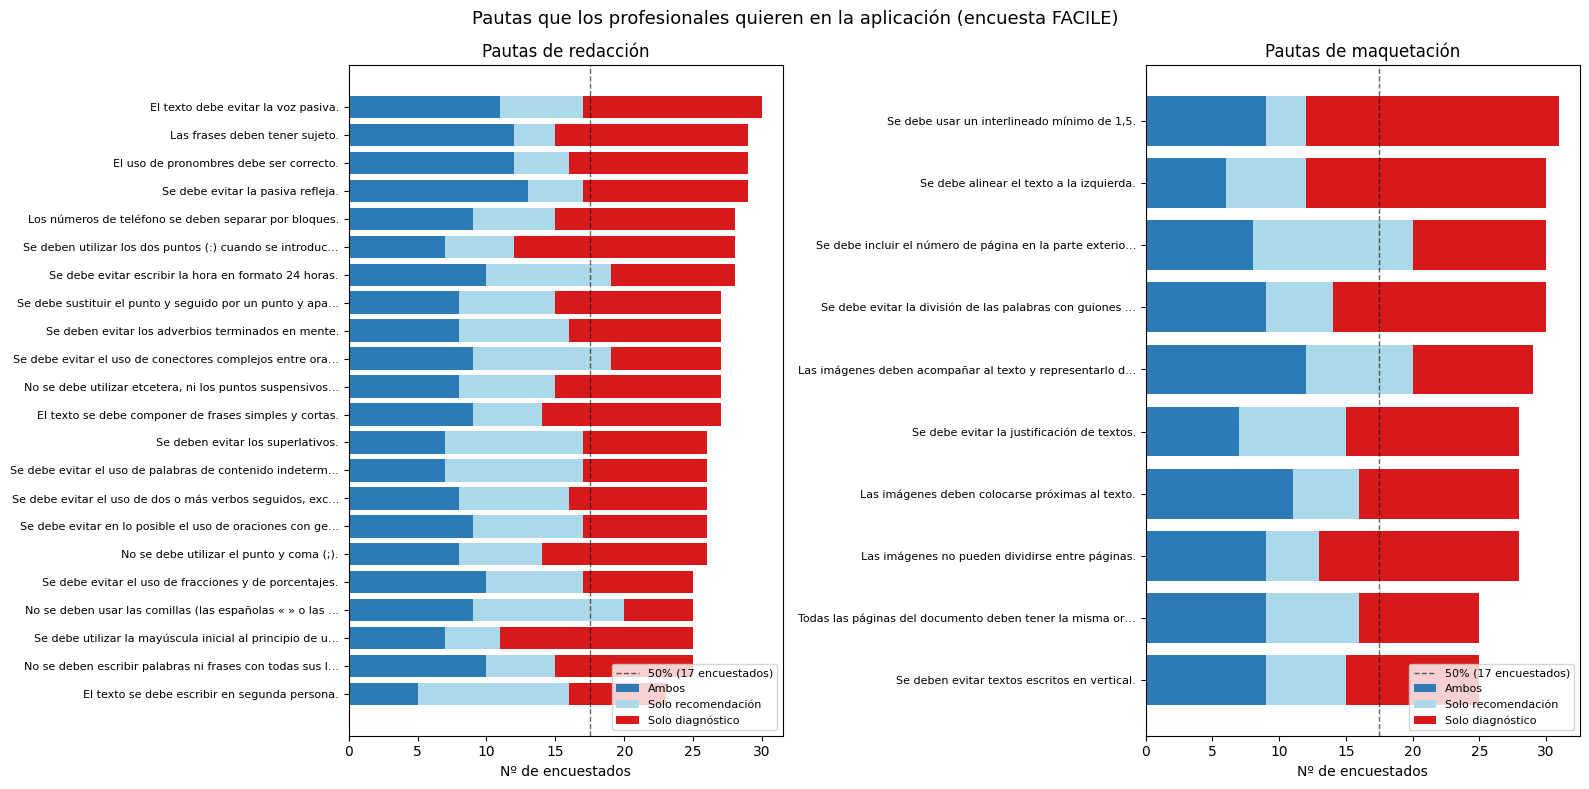

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, tipo, df_sub in [
    (axes[0], 'redacción',   survey_writing_df),
    (axes[1], 'maquetación', survey_layout_df),
]:
    df_plot = df_sub.sort_values('total_seleccionado', ascending=True)
    labels = [t[:55] + '…' if len(t) > 55 else t for t in df_plot['pauta_texto'].astype(str)]
    ax.barh(labels, df_plot['ambos'],             color='#2c7bb6', label='Ambos')
    ax.barh(labels, df_plot['solo_recomendacion'],
            left=df_plot['ambos'],                color='#abd9e9', label='Solo recomendación')
    ax.barh(labels, df_plot['solo_diagnostico'],
            left=df_plot['ambos'] + df_plot['solo_recomendacion'],
                                                  color='#d7191c', label='Solo diagnóstico')
    ax.axvline(x=threshold, color='black', linestyle='--', linewidth=1,
               alpha=0.6, label=f'50% ({int(threshold)} encuestados)')
    ax.set_xlabel('Nº de encuestados')
    ax.set_title(f'Pautas de {tipo}')
    ax.legend(loc='lower right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Pautas que los profesionales quieren en la aplicación (encuesta FACILE)', fontsize=13)
plt.tight_layout()
plt.show()

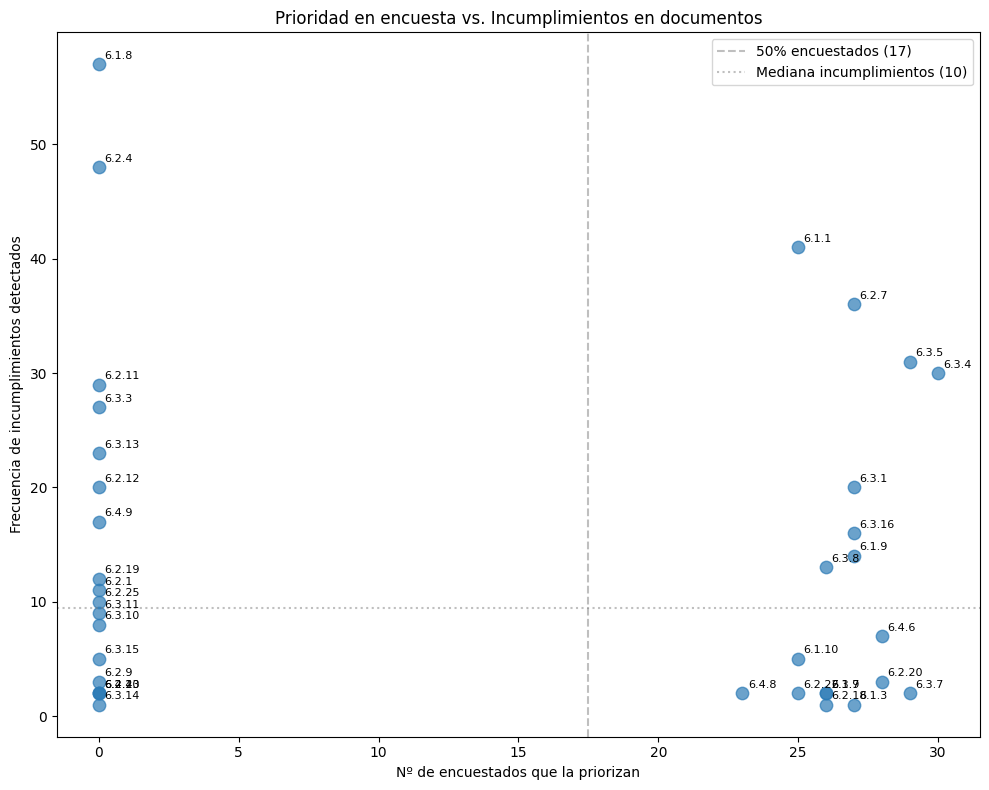

In [14]:
df_scatter = contrast_df[
    (contrast_df['code'] != 'sin_código') & contrast_df['code'].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    df_scatter['total_seleccionado'],
    df_scatter['Frecuencia_violaciones'],
    alpha=0.7, s=80, color='#2c7bb6',
)
for _, row in df_scatter.iterrows():
    ax.annotate(
        str(row['code']),
        xy=(row['total_seleccionado'], row['Frecuencia_violaciones']),
        xytext=(4, 4), textcoords='offset points', fontsize=8,
    )

median_viol = freq_by_code['Frecuencia_violaciones'].median()
ax.axvline(x=threshold,   color='gray', linestyle='--', alpha=0.5,
           label=f'50% encuestados ({int(threshold)})')
ax.axhline(y=median_viol, color='gray', linestyle=':',  alpha=0.5,
           label=f'Mediana incumplimientos ({median_viol:.0f})')
ax.set_xlabel('Nº de encuestados que la priorizan')
ax.set_ylabel('Frecuencia de incumplimientos detectados')
ax.set_title('Prioridad en encuesta vs. Incumplimientos en documentos')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
quadrant_order = [
    'Alta prioridad confirmada',
    'Ampliar cobertura',
    'Detectado sin priorizar',
    'Baja relevancia',
]
sep = '=' * 64
for q in quadrant_order:
    subset = contrast_df[contrast_df['cuadrante'] == q].sort_values(
        'total_seleccionado', ascending=False
    )
    print(f'\n{sep}')
    print(f'  {q}  ({len(subset)} pautas)')
    print(sep)
    for _, row in subset.iterrows():
        code = str(row['code']) if pd.notna(row['code']) else '—'
        sel  = int(row['total_seleccionado'])
        viol = int(row['Frecuencia_violaciones'])
        desc = str(row['Description']) if pd.notna(row['Description']) else '—'
        desc_short = desc[:60] + '…' if len(desc) > 60 else desc
        print(f'  [{code:6s}]  sel={sel:2d}  viol={viol:3d}  {desc_short}')


  Alta prioridad confirmada  (18 pautas)
  [6.3.4 ]  sel=30  viol= 30  Evitar la voz pasiva.
  [6.3.5 ]  sel=29  viol= 31  Evitar la pasiva refleja.
  [6.3.7 ]  sel=29  viol=  2  Evitar oraciones impersonales.
  [6.2.20]  sel=28  viol=  3  Separar los números de teléfono por bloques.
  [6.4.6 ]  sel=28  viol=  7  Usar listado si hay varios elementos.
  [6.3.1 ]  sel=27  viol= 20  Frases sencillas; evitar oraciones complejas.
  [6.3.16]  sel=27  viol= 16  Evitar conectores complejos (por lo tanto, no obstante, por …
  [6.1.3 ]  sel=27  viol=  1  Usar punto y aparte para separar ideas diferentes.
  [6.2.7 ]  sel=27  viol= 36  Evitar adverbios terminados en -mente.
  [6.1.9 ]  sel=27  viol= 14  No utilizar etcétera ni puntos suspensivos (…).
  [6.3.9 ]  sel=26  viol=  2  Evitar dos o más verbos seguidos (salvo perífrasis con deber…
  [6.3.8 ]  sel=26  viol= 13  Evitar oraciones con gerundio.
  [6.1.7 ]  sel=26  viol=  2  No utilizar el punto y coma (;).
  [6.2.18]  sel=26  viol=  1  Evit

## Conclusiones

### Alta prioridad confirmada
Pautas que los profesionales consideran importantes **y** que ya presentan
incumplimientos detectados en los documentos analizados.
Son candidatas a tener mayor peso en el sistema de diagnóstico y en la
generación de recomendaciones.

### Ampliar cobertura
Pautas valoradas por los profesionales pero no detectadas en el análisis
documental actual. Pueden indicar áreas donde el análisis automático
debe mejorarse o donde los documentos analizados no las incumplían.

### Detectado sin priorizar
Pautas con incumplimientos frecuentes pero que los encuestados no priorizaron
explícitamente. Pueden ser pautas que los adaptadores consideran obvias
o que detectan fácilmente de forma manual.

### Pautas de maquetación (Q3)
Las 10 pautas de diseño y formato de la encuesta no están cubiertas por
el rango de códigos 6.1–6.4 del análisis documental (que se centra en
tipografía, vocabulario y estructura oracional). Representan una capa
adicional de análisis a incorporar en futuras versiones de la herramienta.